# **Advanced Data Handling with Pandas**
### Theme: Data wrangling, cleaning, and feature extraction from mutation and CNV(CNA) data
- Audience: Students or researchers working with genomic data (bioinformatics, ML, data science)


CNV - Copy number variation
CNA - Copy number alteration

## 🎯 Learning Objectives
By the end of the class, students will be able to:

 - Use pandas to load, inspect, and clean genomic datasets (mutation & CNV).

 - Merge and structure mutation/CNA data for downstream ML analysis.

 - Perform basic and advanced feature extraction & transformation.

 - Understand how clean, structured data impacts ML outcomes in genomics.

## 🧭 Introduction

Structured  genomic data refers to genetic information stored in tabular form (rows & columns), where each row often represents a patient/sample, and each column represents a measurable attribute (gene mutation status, copy number variation score, etc.).

Example:

- Row: Patient_ID: P12345

- Columns: TP53_mutation: 1 (mutated), BRCA1_mutation: 0 (wild-type), Age: 54, Cancer_Type: "Breast".

we called them structured data because data is organized like a spreadsheet or database table. it is easy to filter, sort, and group and analyze using tools like Pandas

**Why Pandas?**
Pandas is a Python library for data manipulation & analysis. Think of it as Excel on steroids — faster, more powerful, and programmable.

Advantages for genomic data:

- Easy import/export — Load data from CSV, Excel, SQL, or directly from online sources.

- Data cleaning — Handle missing mutation calls, invalid CNV scores.

- Feature engineering — Create new biological features like mutation burden per patient.

- Integration — Merge mutation data with clinical metadata for richer analysis.

- Scalability — Handle thousands of patients and tens of thousands of genomic features.

This can be used for **Cancer classification**, **mutation impact prediction**, **copy number alteration profiling**, and **personalized medicine**.

## 📥 Dataset Source & Setup

✅ Where to Download the Data
We’ll work with public cancer genomics datasets that are widely used in research:

cBioPortal.org – a leading open platform hosting large-scale cancer genomics studies like:

- TCGA-BRCA (The Cancer Genome Atlas – Breast Invasive Carcinoma)

- TCGA-LUAD (The Cancer Genome Atlas – Lung Adenocarcinoma)

These datasets contain mutation and copy number alteration (CNA) data for the same patient cohort, which is important for integration and cross-analysis.

We will work on a breast cancer data for this couurse as practice. - mutation data and CNA data

- #### Mutation data records changes in the DNA sequence (e.g., point mutations, insertions, deletions) that can alter gene function.

- #### CNA (Copy Number Alteration) data captures gains or losses of large DNA segments, leading to abnormal numbers of gene copies.

They are related because both describe genomic alterations affecting gene expression and function. In studies, combining them helps identify cancer drivers, understand disease mechanisms, and develop biomarkers or therapeutic targets.

## 🧼 Data Loading & Initial Inspection

📥 Step 1 — Load Mutation & CNA Data into Pandas
Once you’ve downloaded the mutation (.maf / .csv) and CNV (.tsv / .csv) files, start by loading them into Pandas DataFrames.

In [1]:

#csv = comma separated values
#tsv = tab separated values
#seg = segment file format used in CNV analysis




First off, loading the CNA data

In [2]:
import pandas as pd

cna_df = pd.read_csv("../data/combined_study_segments.seg", sep="\t") # read the data into the cnv_df variable 

print(list(cna_df.columns))

print(cna_df.shape)
cna_df.head() # or cna_df.tail(27) to see the last 27 rows

['ID', 'chrom', 'loc.start', 'loc.end', 'num.mark', 'seg.mean']
(374643, 6)


,ID,chrom,loc.start,loc.end,num.mark,seg.mean
0,TCGA-3C-AAAU-01,1,3301765,30796057,14835,0.1480
1,TCGA-3C-AAAU-01,1,30796407,43298773,6807,0.1731
2,TCGA-3C-AAAU-01,1,43299010,45856106,1309,0.1470
3,TCGA-3C-AAAU-01,1,45856171,53321961,3699,0.2135
4,TCGA-3C-AAAU-01,1,53322607,54960768,1023,0.1765


In [3]:

# Load the clinical data 
clinical_df = pd.read_csv("../data/combined_study_clinical_data.tsv", sep="\t")

print(clinical_df.shape)  # (rows, columns)
print(list(clinical_df.columns))

clinical_df.head()

# Load the CNA data


(1105, 300)
['Study ID', 'Patient ID', 'Sample ID', 'Diagnosis Age', 'Diagnosis Age (days)', 'Alternative Therapy Given', 'Other Alternative Therapy Given', 'Analysis Cohort', 'BCR ABL1 Status', 'Bone Marrow Blasts Day 15', 'Bone Marrow Blasts Day 29', 'Bone Marrow Blasts Day 43', 'Bone Marrow Blasts Day 8', 'Bone Marrow Site of Relapse', 'Cancer Type', 'Cancer Type Detailed', 'Cell of tumor origin', 'CNS Site of Relapse', 'CNS Status', 'Congenital Abnormality', 'Death from Initial Pathologic Diagnosis Date', 'Time To Event (days)', 'DNA Index', 'Ethnicity Category', 'ETV6-RUNX1 Fusion Status', 'First Event', 'Fraction Genome Altered', 'Karyotype', 'MLL Status', 'Molecular Subtype', 'MRD Percentage at end of Consolidation', 'MRD Percentage at end of Consolidation Sensitivity', 'MRD Percentage Day 29', 'MRD Percentage Day 29 Sensitivity', 'MRD Percentage Day 43', 'MRD Percentage Day 43 Sensitivity', 'MRD Percentage Day 8', 'MRD Percentage Day 8 Sensitivity', 'Mutation Count', 'Oncotree 

,Study ID,Patient ID,Sample ID,Diagnosis Age,Diagnosis Age (days),Alternative Therapy Given,Other Alternative Therapy Given,Analysis Cohort,BCR ABL1 Status,Bone Marrow Blasts Day 15,...,Treatment VS-4718,Treatment XL147,Treatment XL765,Neoplasm American Joint Committee on Cancer Clinical Group Stage,Histological Type,ICD-0-3-T,"International Classification of Diseases for Oncology, Third Edition ICD-O-3 Site Code",Patient Death Reason,Event Type,Histology Classification in Primary Tumor
0,brca_tcga_gdc,TCGA-3C-AAAU,TCGA-3C-AAAU-01,55.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,brca_tcga_gdc,TCGA-3C-AALI,TCGA-3C-AALI-01,50.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,brca_tcga_gdc,TCGA-3C-AALJ,TCGA-3C-AALJ-01,62.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,brca_tcga_gdc,TCGA-3C-AALK,TCGA-3C-AALK-01,52.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,brca_tcga_gdc,TCGA-4H-AAAK,TCGA-4H-AAAK-01,50.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Clinical
print("\n--- Clinical Data Summary ---")
clinical_df.describe(include='all') # by default it gives summary statistics for numeric columns


#NaN - Not a Number, used to represent missing or undefined values in pandas DataFrames, Null, None


--- Clinical Data Summary ---


,Study ID,Patient ID,Sample ID,Diagnosis Age,Diagnosis Age (days),Alternative Therapy Given,Other Alternative Therapy Given,Analysis Cohort,BCR ABL1 Status,Bone Marrow Blasts Day 15,...,Treatment VS-4718,Treatment XL147,Treatment XL765,Neoplasm American Joint Committee on Cancer Clinical Group Stage,Histological Type,ICD-0-3-T,"International Classification of Diseases for Oncology, Third Edition ICD-O-3 Site Code",Patient Death Reason,Event Type,Histology Classification in Primary Tumor
count,1105,1105,1105,1089.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
unique,1,1098,1105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,brca_tcga_gdc,TCGA-AC-A6IX,TCGA-Z7-A8R6-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1105,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,58.490358,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,13.203656,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,26.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,49.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,58.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# CNA
print("\n--- CNA Data Summary ---")
cna_df.describe()


--- CNA Data Summary ---


,loc.start,loc.end,num.mark,seg.mean
count,3.746430e+05,3.746430e+05,374643.000000,374643.000000
mean,7.197357e+07,8.042524e+07,4612.060773,0.006843
std,5.473338e+07,5.532683e+07,11266.010035,0.882906
min,2.838680e+05,2.840180e+05,2.000000,-7.681500
25%,2.886805e+07,3.697099e+07,64.000000,-0.228200
50%,6.125298e+07,6.943786e+07,610.000000,0.054800
75%,1.052536e+08,1.146617e+08,3692.000000,0.346000
max,2.476504e+08,2.476510e+08,132283.000000,5.770300


In [6]:

# Unique patients in each
print("\nUnique patients in clinical:", clinical_df["Patient ID"].nunique())
print("Unique samples in CNA:", cna_df["ID"].nunique())


Unique patients in clinical: 1098
Unique samples in CNA: 1100


In [7]:
# Quick Checks for Overlap

# Check if all CNA samples are in clinical data
cna_ids = set(cna_df["ID"])
clinical_sample_ids = set(clinical_df["Sample ID"])

overlap = cna_ids.intersection(clinical_sample_ids)
print(f"Overlap between CNA and clinical samples: {len(overlap)}")

Overlap between CNA and clinical samples: 1100


In [8]:
clinical_df['Sample ID'].value_counts()

Sample ID
TCGA-Z7-A8R6-01    1
TCGA-S3-AA0Z-01    1
TCGA-S3-A6ZH-01    1
TCGA-S3-A6ZG-01    1
TCGA-S3-A6ZF-01    1
                  ..
TCGA-5L-AAT0-01    1
TCGA-4H-AAAK-01    1
TCGA-3C-AALK-01    1
TCGA-3C-AALJ-01    1
TCGA-3C-AALI-01    1
Name: count, Length: 1105, dtype: int64

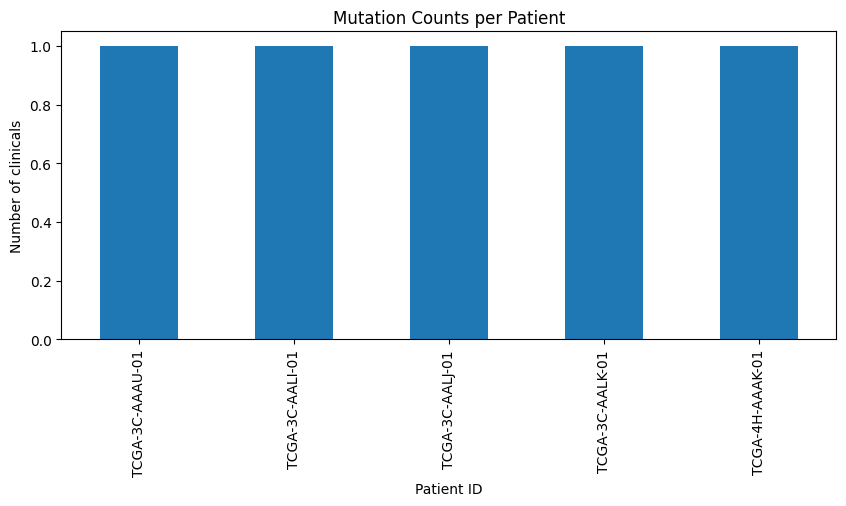

In [9]:
# Quick Visual Check: Mutation Counts per Patient

import matplotlib.pyplot as plt

clinical_5 = clinical_df.head(5)

clinical_counts = clinical_5['Sample ID'].value_counts()

clinical_counts.plot(kind='bar', figsize=(10,4))
plt.xlabel("Patient ID")
plt.ylabel("Number of clinicals")
plt.title("Mutation Counts per Patient")
plt.show()


## 🧹 Data Cleaning – Mutation & CNA Data
Cleaning is one of the most important steps before integrating mutation and CNV datasets for downstream ML tasks. This section ensures the data is consistent, merge-ready, and free from obvious errors.

In [10]:
gloria = clinical_df.isnull().sum()
gloria[gloria > 0].sort_values(ascending=False)

Histology Classification in Primary Tumor    1105
Event Type                                   1105
Diagnosis Age (days)                         1105
Alternative Therapy Given                    1105
Other Alternative Therapy Given              1105
                                             ... 
Patient's Vital Status                          1
Biopsy Site                                     1
Overall Survival (Months)                       1
Overall Survival Status                         1
Sex                                             1
Length: 286, dtype: int64

In [11]:
# 3a. Check for missing values
missing_clinical = clinical_df.isnull().sum()
print("\nMissing values in clinical data (top 20):")
print(missing_clinical[missing_clinical > 0].sort_values(ascending=False).head(20))

# 3b. Fill or drop missing values in key columns
# Example: For numeric columns like 'Mutation Count' fill missing with 0 or median
clinical_df['Mutation Count'] = clinical_df['Mutation Count'].fillna(0)

# For categorical columns, fill with 'Unknown'
categorical_cols = ['Sex', 'Race Category', 'Cancer Type', 'Overall Survival Status']
for col in categorical_cols:
    if col in clinical_df.columns:
        clinical_df[col] = clinical_df[col].fillna('Unknown')

# 3c. Convert numeric columns that may be objects to proper numeric
cols_to_numeric = ['Mutation Count', 'Overall Survival Days', 'Diagnosis Age']
for col in cols_to_numeric:
    if col in clinical_df.columns:
        clinical_df[col] = pd.to_numeric(clinical_df[col], errors='coerce')

# 3d. Remove duplicates if any
clinical_df = clinical_df.drop_duplicates()

print("\nAfter cleaning, clinical data shape:", clinical_df.shape)





Missing values in clinical data (top 20):
Histology Classification in Primary Tumor    1105
Event Type                                   1105
Diagnosis Age (days)                         1105
Alternative Therapy Given                    1105
Other Alternative Therapy Given              1105
Analysis Cohort                              1105
BCR ABL1 Status                              1105
Bone Marrow Blasts Day 15                    1105
Bone Marrow Blasts Day 29                    1105
Bone Marrow Blasts Day 43                    1105
Bone Marrow Blasts Day 8                     1105
Bone Marrow Site of Relapse                  1105
Cell of tumor origin                         1105
Treatment SU11248                            1105
Treatment STF-118804                         1105
Treatment STA9090 (GANETESPIB)               1105
Treatment SORAFENIB                          1105
Treatment SGN-CD19A                          1105
Treatment SGI-1776                           1105
Treatme

In [12]:
# 4a. Check for missing values
missing_cna = cna_df.isnull().sum()
print("\nMissing values in cna data:")
print(missing_cna)

# 4b. Check for invalid chromosome entries, normalize chromosome names
# For example, remove 'chr' prefix if present, ensure chromosomes are strings
cna_df['chrom'] = cna_df['chrom'].astype(str).str.replace('chr', '', regex=False)

# 4c. Convert numeric columns to proper types
num_cols = ['loc.start', 'loc.end', 'num.mark', 'seg.mean']
for col in num_cols:
    cna_df[col] = pd.to_numeric(cna_df[col], errors='coerce')

# 4d. Drop rows with critical missing data (e.g., loc.start or loc.end)
cna_df = cna_df.dropna(subset=['loc.start', 'loc.end'])

# 4e. Remove duplicates if any
cna_df = cna_df.drop_duplicates()

print("\nAfter cleaning, cna data shape:", cna_df.shape)



Missing values in cna data:
ID           0
chrom        0
loc.start    0
loc.end      0
num.mark     0
seg.mean     0
dtype: int64

After cleaning, cna data shape: (374643, 6)


## 🔗 Merging Mutation and CNV Data
Once the mutation and CNV datasets have been cleaned and standardized (especially sample/patient IDs), the next step is to combine them into a unified dataset for downstream analysis. This step ensures that for each patient/sample, we can see both mutation events and copy number variations.

Key Considerations Before Merging
- Unique identifiers:
Ensure both datasets have a common identifier column (e.g., sample_id, patient_id). If IDs differ in format (e.g., "PAT-001" vs "001"), standardize them during cleaning.

- Granularity:
Are we merging per-patient or per-sample? Decide based on your analysis needs.

- Data alignment:
Ensure date/time stamps, sequencing platforms, or batch codes don’t create mismatches.

In [13]:
important_cols = [
    'Patient ID', 'Sample ID', 'Mutation Count', 'Overall Survival Days', 
    'Overall Survival Status', 'Cancer Type', 'Sex', 'Age at Diagnosis', 
    'TMB (nonsynonymous)', 'Risk Group', 'Molecular Subtype'
]
clinical_sub = clinical_df[important_cols].copy()


In [14]:
cna_df.head()

,ID,chrom,loc.start,loc.end,num.mark,seg.mean
0,TCGA-3C-AAAU-01,1,3301765,30796057,14835,0.1480
1,TCGA-3C-AAAU-01,1,30796407,43298773,6807,0.1731
2,TCGA-3C-AAAU-01,1,43299010,45856106,1309,0.1470
3,TCGA-3C-AAAU-01,1,45856171,53321961,3699,0.2135
4,TCGA-3C-AAAU-01,1,53322607,54960768,1023,0.1765


In [15]:
# Create flags for gain/loss (threshold can be +/- 0.2 as example)
cna_df['gain'] = cna_df['seg.mean'] > 0.2
cna_df['loss'] = cna_df['seg.mean'] < -0.2

# Aggregate per sample
cnv_summary = cna_df.groupby('ID').agg(
    total_segments = ('seg.mean', 'count'),
    mean_seg_mean = ('seg.mean', 'mean'),
    gain_segments = ('gain', 'sum'),
    loss_segments = ('loss', 'sum')
).reset_index()

# Calculate fraction gains/losses
cnv_summary['frac_gain'] = cnv_summary['gain_segments'] / cnv_summary['total_segments']
cnv_summary['frac_loss'] = cnv_summary['loss_segments'] / cnv_summary['total_segments']


In [16]:
cna_df.head()

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,gain,loss
0,TCGA-3C-AAAU-01,1,3301765,30796057,14835,0.1480,False,False
1,TCGA-3C-AAAU-01,1,30796407,43298773,6807,0.1731,False,False
2,TCGA-3C-AAAU-01,1,43299010,45856106,1309,0.1470,False,False
3,TCGA-3C-AAAU-01,1,45856171,53321961,3699,0.2135,True,False
4,TCGA-3C-AAAU-01,1,53322607,54960768,1023,0.1765,False,False


In [17]:
cnv_summary.head()

,ID,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss
0,TCGA-3C-AAAU-01,657,0.206238,340,202,0.517504,0.307458
1,TCGA-3C-AALI-01,622,0.102380,285,184,0.458199,0.295820
2,TCGA-3C-AALJ-01,600,0.254705,304,165,0.506667,0.275000
3,TCGA-3C-AALK-01,150,-0.094641,28,32,0.186667,0.213333
4,TCGA-4H-AAAK-01,172,-0.150607,23,46,0.133721,0.267442


In [18]:
merged_df = pd.merge(
    clinical_sub,
    cnv_summary,
    how='left',
    left_on='Sample ID',
    right_on='ID'
)

# Drop redundant 'ID' column from CNV summary after merge
merged_df = merged_df.drop(columns=['ID'])
merged_df.head()

,Patient ID,Sample ID,Mutation Count,Overall Survival Days,Overall Survival Status,Cancer Type,Sex,Age at Diagnosis,TMB (nonsynonymous),Risk Group,Molecular Subtype,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,18.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,657.0,0.206238,340.0,202.0,0.517504,0.307458
1,TCGA-3C-AALI,TCGA-3C-AALI-01,408.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,622.0,0.102380,285.0,184.0,0.458199,0.295820
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,25.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,600.0,0.254705,304.0,165.0,0.506667,0.275000
3,TCGA-3C-AALK,TCGA-3C-AALK-01,40.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,150.0,-0.094641,28.0,32.0,0.186667,0.213333
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,15.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,172.0,-0.150607,23.0,46.0,0.133721,0.267442


In [19]:
print("Merged data shape:", merged_df.shape)
print("\nMissing CNV data after merge:", merged_df['total_segments'].isnull().sum())
merged_df.head(5)


Merged data shape: (1105, 17)

Missing CNV data after merge: 5


,Patient ID,Sample ID,Mutation Count,Overall Survival Days,Overall Survival Status,Cancer Type,Sex,Age at Diagnosis,TMB (nonsynonymous),Risk Group,Molecular Subtype,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,18.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,657.0,0.206238,340.0,202.0,0.517504,0.307458
1,TCGA-3C-AALI,TCGA-3C-AALI-01,408.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,622.0,0.102380,285.0,184.0,0.458199,0.295820
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,25.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,600.0,0.254705,304.0,165.0,0.506667,0.275000
3,TCGA-3C-AALK,TCGA-3C-AALK-01,40.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,150.0,-0.094641,28.0,32.0,0.186667,0.213333
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,15.0,NaN,0:LIVING,Invasive Breast Carcinoma,Female,NaN,NaN,NaN,NaN,172.0,-0.150607,23.0,46.0,0.133721,0.267442


In [20]:
merged_df.isnull().sum()

Patient ID                    0
Sample ID                     0
Mutation Count                0
Overall Survival Days      1105
Overall Survival Status       0
Cancer Type                   0
Sex                           0
Age at Diagnosis           1105
TMB (nonsynonymous)        1105
Risk Group                 1105
Molecular Subtype          1105
total_segments                5
mean_seg_mean                 5
gain_segments                 5
loss_segments                 5
frac_gain                     5
frac_loss                     5
dtype: int64

Code to remove columns with too many missing values (NaNs)

In [21]:
merged_df['mean_seg_mean'].isnull().mean()

np.float64(0.004524886877828055)

In [22]:

# Set threshold for max allowed missing ratio (e.g., 0.2 for 20%)
threshold = 0.2

# Calculate missing value ratio per column
missing_ratio = merged_df.isnull().mean()

# Filter columns to keep: those with missing ratio <= threshold
cols_to_keep = missing_ratio[missing_ratio <= threshold].index

# Filter the dataframe
merged_df_clean = merged_df[cols_to_keep].copy()

print(f"Columns dropped due to missing values: {list(missing_ratio[missing_ratio > threshold].index)}")
print(f"Remaining columns: {list(merged_df_clean.columns)}")

Columns dropped due to missing values: ['Overall Survival Days', 'Age at Diagnosis', 'TMB (nonsynonymous)', 'Risk Group', 'Molecular Subtype']
Remaining columns: ['Patient ID', 'Sample ID', 'Mutation Count', 'Overall Survival Status', 'Cancer Type', 'Sex', 'total_segments', 'mean_seg_mean', 'gain_segments', 'loss_segments', 'frac_gain', 'frac_loss']


In [23]:
list(merged_df_clean.columns)

['Patient ID',
 'Sample ID',
 'Mutation Count',
 'Overall Survival Status',
 'Cancer Type',
 'Sex',
 'total_segments',
 'mean_seg_mean',
 'gain_segments',
 'loss_segments',
 'frac_gain',
 'frac_loss']

In [24]:
merged_df_clean.isnull().sum(  )

Patient ID                 0
Sample ID                  0
Mutation Count             0
Overall Survival Status    0
Cancer Type                0
Sex                        0
total_segments             5
mean_seg_mean              5
gain_segments              5
loss_segments              5
frac_gain                  5
frac_loss                  5
dtype: int64

In [25]:
merged_df_clean.head()

,Patient ID,Sample ID,Mutation Count,Overall Survival Status,Cancer Type,Sex,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,18.0,0:LIVING,Invasive Breast Carcinoma,Female,657.0,0.206238,340.0,202.0,0.517504,0.307458
1,TCGA-3C-AALI,TCGA-3C-AALI-01,408.0,0:LIVING,Invasive Breast Carcinoma,Female,622.0,0.102380,285.0,184.0,0.458199,0.295820
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,25.0,0:LIVING,Invasive Breast Carcinoma,Female,600.0,0.254705,304.0,165.0,0.506667,0.275000
3,TCGA-3C-AALK,TCGA-3C-AALK-01,40.0,0:LIVING,Invasive Breast Carcinoma,Female,150.0,-0.094641,28.0,32.0,0.186667,0.213333
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,15.0,0:LIVING,Invasive Breast Carcinoma,Female,172.0,-0.150607,23.0,46.0,0.133721,0.267442


### Possible ML Projects from our processed multi-omic (clinical and CNA data)

- Survival Analysis: Predict overall survival time or survival status (alive/deceased) using mutation counts, CNV features, and clinical info.

- Subtype Classification: Predict molecular subtype or cancer type from mutation and CNV data.

- Mutation Burden Prediction: Explore regression models to predict mutation rate from clinical features.

In [ ]:
#merged_df_clean.to_csv("../data/merged_clinical(mutation)_cna_data.csv", index=False)